In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [2]:

df = pd.read_csv("../data/raw/flight_data_2024.csv")

print(f"Shape: {df.shape}")
df.head()

C:\Users\mtawa\AppData\Local\Temp\ipykernel_620\502205704.py:1: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/flight_data_2024.csv")


Shape: (7079081, 35)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [3]:
# Missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False))

# Data types
print("\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===
                     Missing Count  Missing %
cancellation_code          6982766      98.64
air_time                    113814       1.61
actual_elapsed_time         113814       1.61
arr_delay                   113814       1.61
arr_time                     97854       1.38
wheels_on                    97856       1.38
taxi_in                      97856       1.38
wheels_off                   95734       1.35
taxi_out                     95734       1.35
dep_delay                    92970       1.31
dep_time                     92659       1.31
op_carrier_fl_num                1       0.00
crs_elapsed_time                 1       0.00

=== Data Types ===
year                     int64
month                    int64
day_of_month             int64
day_of_week              int64
fl_date                    str
op_unique_carrier          str
op_carrier_fl_num      float64
origin                     str
origin_city_name           str
origin_state_nm            str
des

In [4]:
# Step 1 — Drop useless columns
cols_to_drop = [
    'cancellation_code',   # 98.64% missing
    'year',                # only one value
    'day_of_month',        # not in feature list
    'fl_date',             # month & day_of_week already exist
    'origin_city_name', 'origin_state_nm',   # redundant with origin IATA
    'dest_city_name', 'dest_state_nm',       # redundant with dest IATA
    'op_carrier_fl_num',   # flight number, not predictive
    # Operational columns (not known at booking time = leakage)
    'dep_time', 'wheels_off', 'wheels_on',
    'taxi_out', 'taxi_in', 'arr_time',
    'actual_elapsed_time', 'air_time',
    # Delay breakdown (known only AFTER landing = leakage)
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay',
    'dep_delay'            # known at departure not at booking
]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Shape after dropping columns: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Shape after dropping columns: (7079081, 12)
Remaining columns: ['month', 'day_of_week', 'op_unique_carrier', 'origin', 'dest', 'crs_dep_time', 'crs_arr_time', 'arr_delay', 'cancelled', 'diverted', 'crs_elapsed_time', 'distance']


In [5]:
# Step 2 — Drop cancelled and diverted flights (no arrival delay = useless for prediction)
df = df[(df['cancelled'] == 0) & (df['diverted'] == 0)]
df.drop(columns=['cancelled', 'diverted'], inplace=True)

print(f"Shape after dropping cancelled/diverted: {df.shape}")
print(f"Remaining nulls:\n{df.isnull().sum()}")

Shape after dropping cancelled/diverted: (6965267, 10)
Remaining nulls:
month                0
day_of_week          0
op_unique_carrier    0
origin               0
dest                 0
crs_dep_time         0
crs_arr_time         0
arr_delay            0
crs_elapsed_time     0
distance             0
dtype: int64


In [6]:
# Step 3 — Engineer features
df['dep_hour'] = (df['crs_dep_time'] // 100).astype(int)  # e.g. 1415 → 14
df['is_weekend'] = df['day_of_week'].isin([6, 7]).astype(int)  # 6=Sat, 7=Sun

# Step 4 — Create target variable
df['is_delayed'] = (df['arr_delay'] > 15).astype(int)

# Step 5 — Drop columns used only for engineering
df.drop(columns=['crs_dep_time', 'crs_arr_time', 'arr_delay'], inplace=True)

print(f"\nFinal shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget distribution:\n{df['is_delayed'].value_counts(normalize=True).round(4) * 100}")
df.head()


Final shape: (6965267, 10)

Columns: ['month', 'day_of_week', 'op_unique_carrier', 'origin', 'dest', 'crs_elapsed_time', 'distance', 'dep_hour', 'is_weekend', 'is_delayed']

Target distribution:
is_delayed
0    79.85
1    20.15
Name: proportion, dtype: float64


,month,day_of_week,op_unique_carrier,origin,dest,crs_elapsed_time,distance,dep_hour,is_weekend,is_delayed
0,1,1,9E,JFK,DTW,136.0,509.0,12,0,0
1,1,1,9E,MSP,CLE,130.0,622.0,10,0,0
2,1,1,9E,JFK,RIC,106.0,288.0,14,0,0
3,1,1,9E,RIC,JFK,111.0,288.0,16,0,0
4,1,1,9E,DTW,MKE,79.0,237.0,10,0,0


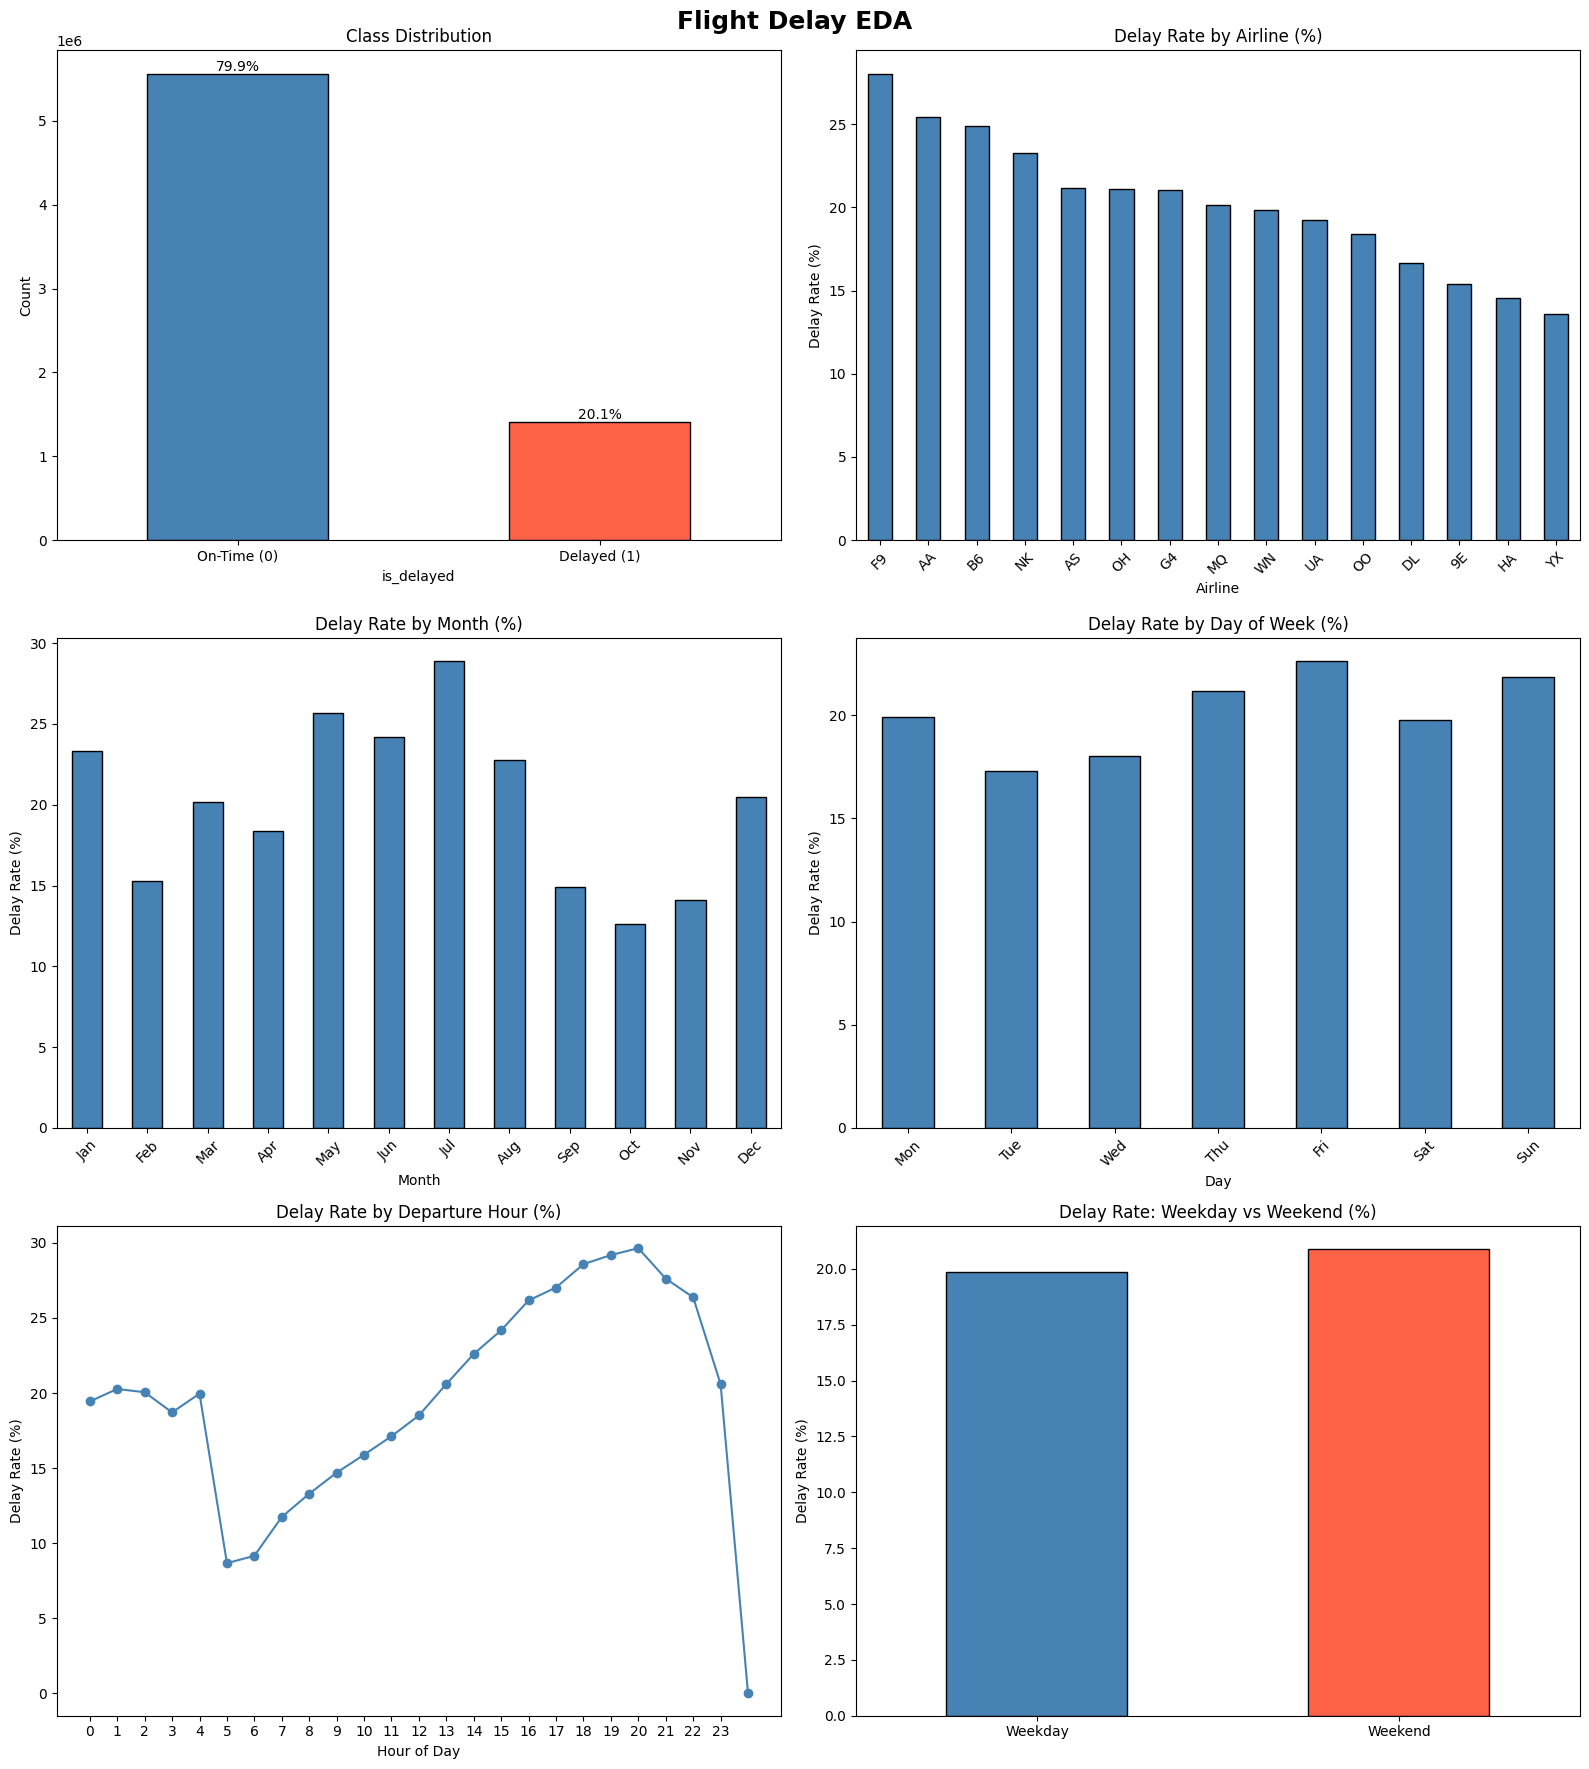

EDA saved to outputs/reports/eda_flight.png


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Flight Delay EDA', fontsize=18, fontweight='bold')

# 1 — Target distribution
ax1 = axes[0, 0]
df['is_delayed'].value_counts().plot(kind='bar', ax=ax1, color=['steelblue', 'tomato'], edgecolor='black')
ax1.set_title('Class Distribution')
ax1.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax1.set_ylabel('Count')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()/len(df)*100:.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom')

# 2 — Delay rate by airline
ax2 = axes[0, 1]
airline_delay = df.groupby('op_unique_carrier')['is_delayed'].mean().sort_values(ascending=False) * 100
airline_delay.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('Delay Rate by Airline (%)')
ax2.set_xlabel('Airline')
ax2.set_ylabel('Delay Rate (%)')
ax2.tick_params(axis='x', rotation=45)

# 3 — Delay rate by month
ax3 = axes[1, 0]
month_delay = df.groupby('month')['is_delayed'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_delay.index = month_names
month_delay.plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black')
ax3.set_title('Delay Rate by Month (%)')
ax3.set_xlabel('Month')
ax3.set_ylabel('Delay Rate (%)')
ax3.tick_params(axis='x', rotation=45)

# 4 — Delay rate by day of week
ax4 = axes[1, 1]
dow_delay = df.groupby('day_of_week')['is_delayed'].mean() * 100
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_delay.index = dow_names
dow_delay.plot(kind='bar', ax=ax4, color='steelblue', edgecolor='black')
ax4.set_title('Delay Rate by Day of Week (%)')
ax4.set_xlabel('Day')
ax4.set_ylabel('Delay Rate (%)')
ax4.tick_params(axis='x', rotation=45)

# 5 — Delay rate by hour
ax5 = axes[2, 0]
hour_delay = df.groupby('dep_hour')['is_delayed'].mean() * 100
hour_delay.plot(kind='line', ax=ax5, color='steelblue', marker='o')
ax5.set_title('Delay Rate by Departure Hour (%)')
ax5.set_xlabel('Hour of Day')
ax5.set_ylabel('Delay Rate (%)')
ax5.set_xticks(range(0, 24))

# 6 — Delay rate by weekend
ax6 = axes[2, 1]
weekend_delay = df.groupby('is_weekend')['is_delayed'].mean() * 100
weekend_delay.index = ['Weekday', 'Weekend']
weekend_delay.plot(kind='bar', ax=ax6, color=['steelblue', 'tomato'], edgecolor='black')
ax6.set_title('Delay Rate: Weekday vs Weekend (%)')
ax6.set_xlabel('')
ax6.set_ylabel('Delay Rate (%)')
ax6.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/reports/eda_flight.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA saved to outputs/reports/eda_flight.png")

In [8]:
# Rename to match report
df.rename(columns={'op_unique_carrier': 'airline'}, inplace=True)

cols_order = [
    'airline',       # 1 - Categorical
    'origin',        # 2 - Categorical
    'dest',          # 3 - Categorical
    'distance',      # 4 - Numerical
    'dep_hour',      # 5 - Numerical
    'day_of_week',   # 6 - Categorical
    'month',         # 7 - Categorical
    'is_weekend',    # 8 - Binary
    'is_delayed'     # Target
]

df = df[cols_order]

print(f"Final columns: {list(df.columns)}")
print(f"Shape: {df.shape}")
df.head()

Final columns: ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed']
Shape: (6965267, 9)


,airline,origin,dest,distance,dep_hour,day_of_week,month,is_weekend,is_delayed
0,9E,JFK,DTW,509.0,12,1,1,0,0
1,9E,MSP,CLE,622.0,10,1,1,0,0
2,9E,JFK,RIC,288.0,14,1,1,0,0
3,9E,RIC,JFK,288.0,16,1,1,0,0
4,9E,DTW,MKE,237.0,10,1,1,0,0


In [9]:
# Save clean dataset
output_path = "../data/processed/flight_features.csv"
df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df.shape}")
print(f"\nFinal columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget distribution:\n{df['is_delayed'].value_counts()}")

Saved: ../data/processed/flight_features.csv
Shape: (6965267, 9)

Final columns: ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed']

Missing values:
airline        0
origin         0
dest           0
distance       0
dep_hour       0
day_of_week    0
month          0
is_weekend     0
is_delayed     0
dtype: int64

Target distribution:
is_delayed
0    5561879
1    1403388
Name: count, dtype: int64
